In [1]:
import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [2]:
DAX = pd.read_csv('Data/GDAXI.csv')

DAX.columns = ['Date', 'Open', 'High', 'Low', 'Close']

DAX['Date'] = pd.to_datetime(DAX['Date'])

DAX = DAX.sort_values(['Date'], axis=0, ascending=True)

DAX['log_return'] = -100* np.log(DAX['Close']).diff()

DAX_train = DAX[:1270]
DAX_test = DAX[1270:]

DAX.head()

C:\Windows\Temp\ipykernel_25408\955824082.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  DAX['Date'] = pd.to_datetime(DAX['Date'])


,Date,Open,High,Low,Close,log_return
5329,2000-01-03,6961.72,6750.76,6750.76,6750.76,NaN
5328,2000-01-04,6747.24,6586.95,6586.95,6586.95,2.456467
5327,2000-01-05,6585.85,6502.07,6502.07,6502.07,1.296983
5326,2000-01-06,6501.45,6474.92,6474.92,6474.92,0.418434
5325,2000-01-07,6489.94,6780.96,6780.96,6780.96,-4.618243


In [3]:
# Var-Cov-Method
mu_hat = DAX_train['log_return'].mean()
sigma_hat = DAX_train['log_return'].std()

print(f'mu: {mu_hat}, sigma: {sigma_hat}')

VaR1_hat = norm.ppf(0.975, mu_hat, sigma_hat)

ES1_hat = mu_hat + sigma_hat * (norm.pdf(norm.ppf(0.975))) / (1-0.975)

print(f'VaR1_hat: {VaR1_hat}, ES1_hat: {ES1_hat}')

mu: 0.036351973387218045, sigma: 1.8363537434079578
VaR1_hat: 3.635539173342123, ES1_hat: 4.329384882195859


In [4]:
#Historical Simulation
VaR2_hat = DAX_train['log_return'].quantile(0.975)

ES2_hat = DAX_train[DAX_train['log_return'] >= VaR2_hat]['log_return'].mean()

print(f'VaR2_hat: {VaR2_hat}, ES2_hat: {ES2_hat}')

VaR2_hat: 3.9412154114456834, ES2_hat: 5.04990452152505


In [5]:
#ES is more conservative, as in higher number, but it means a different thing so not really what I would understand as more conservative.
#Likely due to the wrong normality (i.e. light tailed) assumption Var-Covar-Method provides less conservative estimates. The simulation is naturally closer to the true distribution as it doesn't use a flawed assumption.

In [6]:
VaR3_hat = np.zeros(len(DAX))
ES3_hat = np.zeros(len(DAX))
VaR4_hat = np.zeros(len(DAX))
ES4_hat = np.zeros(len(DAX))

for i in range(len(DAX)):
    # Var-Cov-Method
    mu_hat = DAX['log_return'][:i].mean()
    sigma_hat = DAX['log_return'][:i].std()

    #print(f'mu: {mu_hat}, sigma: {sigma_hat}')

    VaR3_hat[i] = norm.ppf(0.975, mu_hat, sigma_hat)

    ES3_hat[i] = mu_hat + sigma_hat * (norm.pdf(norm.ppf(0.975))) / (1-0.975)

    #print(f'VaR3_hat: {VaR3_hat}, ES3_hat: {ES3_hat}')

    #Historical Simulation
    VaR4_hat[i] = DAX['log_return'][:i].quantile(0.975)
    ES4_hat[i] = DAX[:i][DAX['log_return'][:i] >= VaR4_hat[i]]['log_return'].mean()

    #print(f'L2_hat: {VaR4_hat}, ES4_hat: {ES4_hat}')

In [7]:
print(f'VaR3_hat: {VaR3_hat[1270]}, ES3_hat: {ES3_hat[1270]}')
print(f'VaR4_hat: {VaR4_hat[1270]}, ES4_hat: {ES4_hat[1270]}')

VaR3_hat: 3.635539173342123, ES3_hat: 4.329384882195859
VaR4_hat: 3.9412154114456834, ES4_hat: 5.04990452152505


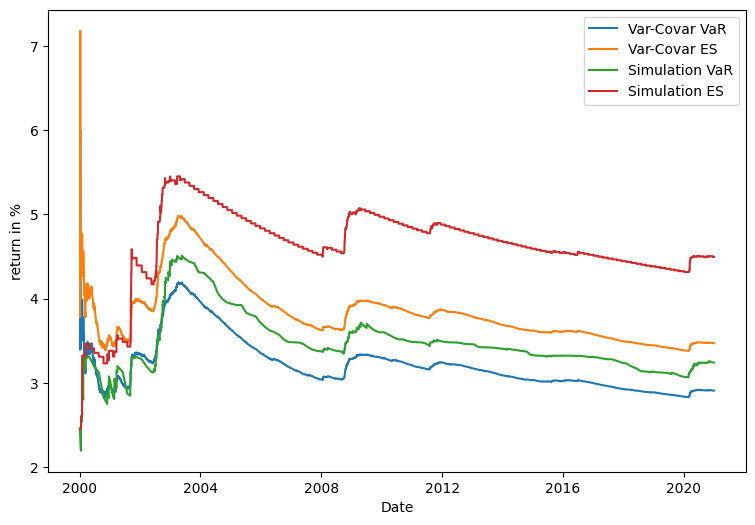

In [8]:
plt.figure(figsize=(9, 6))

plt.plot(DAX['Date'], VaR3_hat, label='Var-Covar VaR')
plt.plot(DAX['Date'], ES3_hat, label='Var-Covar ES')
plt.plot(DAX['Date'], VaR4_hat, label='Simulation VaR')
plt.plot(DAX['Date'], ES4_hat, label='Simulation ES')

plt.xlabel('Date')
plt.ylabel('return in %')
plt.legend(loc='upper right')

plt.show()

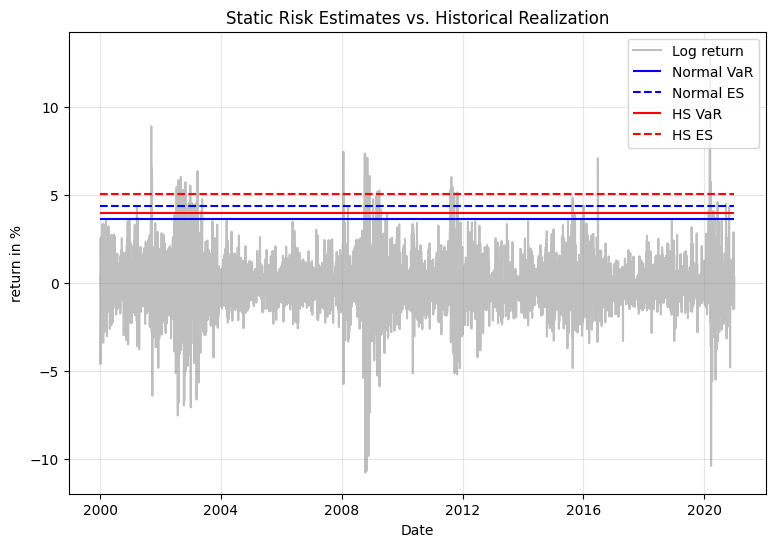

In [9]:
#My plot:
# plt.plot(DAX['Date'], DAX['log_return'])
# plt.hlines(y=[VaR1_hat, VaR2_hat, ES1_hat, ES2_hat], xmin=DAX['Date'].iloc[0], xmax=DAX['Date'].iloc[-1], colors=['r', 'g', 'blue', 'orange'])

# plt.xlabel('Date')
# plt.xlabel('return in %')
# plt.grid()

#Gemini Plot:
plt.figure(figsize=(9, 6))

plt.plot(DAX['Date'], DAX['log_return'], label='Log return', color='gray', alpha=0.5)

plt.hlines(y=VaR1_hat, xmin=DAX['Date'].iloc[0], xmax=DAX['Date'].iloc[-1], 
           color='blue', label='Normal VaR')
plt.hlines(y=ES1_hat, xmin=DAX['Date'].iloc[0], xmax=DAX['Date'].iloc[-1], 
           color='blue', linestyle='--', label='Normal ES')
plt.hlines(y=VaR2_hat, xmin=DAX['Date'].iloc[0], xmax=DAX['Date'].iloc[-1], 
           color='red', label='HS VaR')
plt.hlines(y=ES2_hat, xmin=DAX['Date'].iloc[0], xmax=DAX['Date'].iloc[-1], 
           color='red', linestyle='--', label='HS ES')

plt.xlabel('Date')
plt.ylabel('return in %')
plt.title('Static Risk Estimates vs. Historical Realization')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

Assume your mean-adjusted returns (log-returnes) follow the process:$$r_t = \sigma_t \epsilon_t, \quad \epsilon_t \sim \mathcal{N}(0, 1)$$The conditional variance $\sigma_t^2$ is defined recursively:$$\sigma_t^2 = \omega + \alpha r_{t-1}^2 + \beta \sigma_{t-1}^2$$The parameter vector to estimate is $\theta = (\omega, \alpha, \beta)$. To ensure the process is stationary and the variance is positive, we require:$\omega > 0$$\alpha, \beta \ge 0$$\alpha + \beta < 1$

Under the assumption of normality for the innovations $\epsilon_t$, the conditional distribution of $r_t$ given the information set $\mathcal{F}_{t-1}$ is:$$r_t \mid \mathcal{F}_{t-1} \sim \mathcal{N}(0, \sigma_t^2)$$The Probability Density Function (PDF) for a single observation $t$ is:$$f(r_t \mid \sigma_t^2) = \frac{1}{\sqrt{2\pi\sigma_t^2}} \exp\left( -\frac{r_t^2}{2\sigma_t^2} \right)$$The joint likelihood for the entire sample $T$ is the product of these conditional densities.

Maximizing a product is computationally difficult, so we maximize the Log-Likelihood ($L$), which turns the product into a sum:$$L(\theta) = \sum_{t=1}^T \log\left( f(r_t \mid \sigma_t^2) \right)$$Substituting the PDF and simplifying:$$L(\theta) = -\frac{1}{2} \sum_{t=1}^T \left( \log(2\pi) + \log(\sigma_t^2) + \frac{r_t^2}{\sigma_t^2} \right)$$Since $\log(2\pi)$ is a constant, the optimization focuses on:$$\hat{\theta}_{MLE} = \arg \min_{\theta} \sum_{t=1}^T \left( \log(\sigma_t^2) + \frac{r_t^2}{\sigma_t^2} \right)$$

In [75]:
def garch_NLogLike(params, returns):
    a0, a1, b = params

    T=len(returns)
    var = np.zeros(T)

    var[0] = np.var(returns)
    for t in range(1,T):
        var[t] = a0 + a1*returns[t-1]**2 + b*var[t-1]
    
    return sum(np.log(var) + returns**2/var)

bounds = [(1e-6, None), (0, 1), (0, 1)]
x0 = [0.1, 0.1, 0.8]

res = minimize(garch_NLogLike, x0=x0, args=(DAX_train['log_return'].dropna().values), 
               bounds=bounds, method='L-BFGS-B')

a0, a1, b = res.x
res.x
#alternative:
# from arch import arch_model
# am = arch_model(DAX_train['log_return'].dropna(), vol='Garch', p=1, q=1)
# res_arch = am.fit(update_freq=5, disp='off')

array([0.02253296, 0.09142713, 0.90212368])

In [76]:
#a0, a1, b = 0.02, 0.09, 0.90 #rough estimates by professor

In [77]:
T=len(DAX['log_return'].dropna().values)
var = np.zeros(T)

var[0] = np.var(DAX['log_return'].dropna().values)
for t in range(1,T):
    var[t] = a0 + a1*DAX['log_return'].dropna().values[t-1]**2 + b*var[t-1]

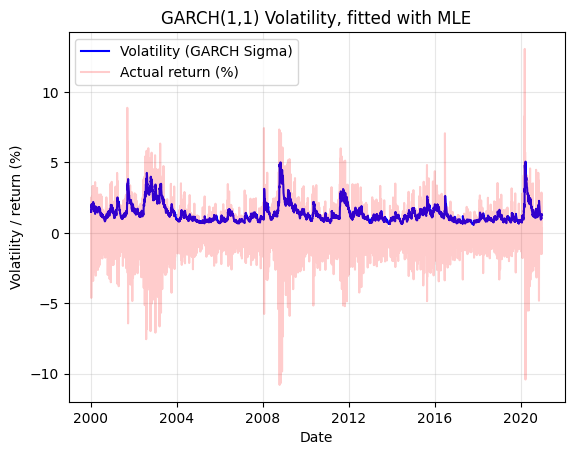

In [78]:
plt.plot(DAX['Date'].dropna()[1:], np.sqrt(var), label='Volatility (GARCH Sigma)', color='blue', linewidth=1.5)
plt.plot(DAX['Date'].dropna()[1:], DAX['log_return'].dropna(), label='Actual return (%)', color='red', alpha=0.2)

plt.grid(True, alpha=0.3)
plt.xlabel('Date')
plt.ylabel('Volatility / return (%)')
plt.title('GARCH(1,1) Volatility, fitted with MLE')
plt.legend()

plt.show()

We can clearly see the volatility clustering and time dependent volatility that we observe in real financial markets.

In [79]:
Z = DAX_train['log_return']/np.sqrt(var[:len(DAX_train)])
Z_mean = Z.mean()
Z_std = Z.std()

print(f'Mean of Z: {round(Z_mean,3)}')
print(f'Standard Deviation of Z: {round(Z_std, 2)}')

Mean of Z: 0.024
Standard Deviation of Z: 0.93


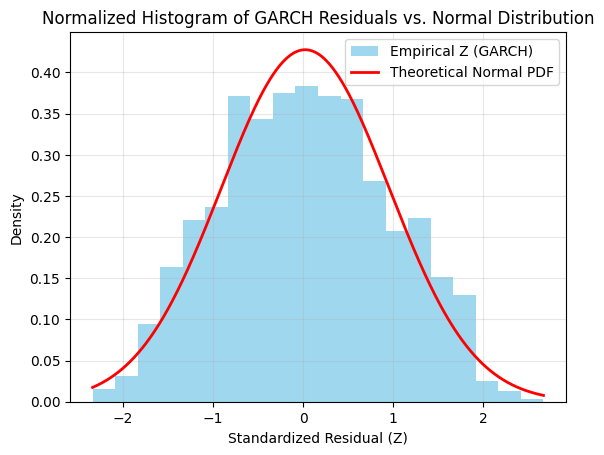

In [80]:
plt.hist(Z, bins=20, density=True, alpha=0.8, color='skyblue', label='Empirical Z (GARCH)')

x_range = np.linspace(Z.min(), Z.max(), 1000)
y_pdf = norm.pdf(x_range, loc=Z_mean, scale=Z_std)
plt.plot(x_range, y_pdf, 'r', lw=2, label='Theoretical Normal PDF')

plt.title('Normalized Histogram of GARCH Residuals vs. Normal Distribution')
plt.xlabel('Standardized Residual (Z)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

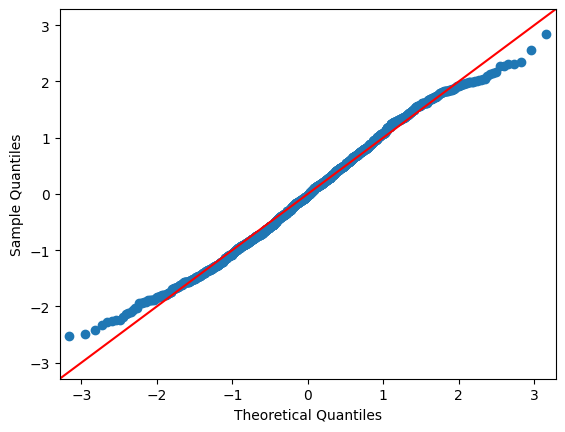

In [84]:
import statsmodels.api as sm
sm.qqplot(Z.dropna(), line ='45', fit=True);

In [85]:
Z_VaR1_hat = norm.ppf(0.975,loc=Z_mean, scale=Z_std)
Z_ES1_hat = Z_mean + Z_std * (norm.pdf(norm.ppf(0.975))) / (1-0.975)

Z_VaR2_hat = Z.quantile(0.975)
Z_ES2_hat = Z[Z>=Z_VaR2_hat].mean() 


print(f'VaR estimate via Var-Covariance: {Z_VaR1_hat}')
print(f'ES estimate via Var-Covariance: {Z_ES1_hat}')
print(f'VaR estimate via Simulation: {Z_VaR2_hat}')
print(f'ES estimate via Var-Simulation: {Z_ES2_hat}')

#as you can see, the QQ plot is not flipped on the diagonal line. The mass is concentrated inside more then with the normal. This matches what we see in the risk metrics. The Var-Covariance method gives the more conservative estimate. 

VaR estimate via Var-Covariance: 1.8527611347826676
ES estimate via Var-Covariance: 2.205223347083063
VaR estimate via Simulation: 1.7679918631738558
ES estimate via Var-Simulation: 1.9716588140255906
